In [1]:
import kagglehub
import shutil
from pathlib import Path

!pip install -q kagglehub


dataset_path = kagglehub.dataset_download("zalando-research/fashionmnist")

source_file = next(Path(dataset_path).rglob("fashion-mnist_train.csv"))
shutil.copy2(source_file, "fashion-mnist_train.csv")

print("Dosya indirildi:", Path("fashion-mnist_train.csv").resolve())

c:\Users\equbi\anaconda3\envs\dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 68.8M/68.8M [00:06<00:00, 11.0MB/s]

Extracting files...


Dosya indirildi: C:\Users\equbi\Desktop\YZ50\Hafta 1\fashion-mnist_train.csv


In [14]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv('fashion-mnist_train.csv')
data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Tipik bir neural network temelde 3 fazdan oluşur:
1. Forward pass: Girdi verisi ağı beslenir ve çıktılar hesaplanır.
2. Loss hesaplama: Modelin tahminleri ile gerçek değerler arasındaki fark hesaplanır.
3. Backward pass: Loss fonksiyonunun türevleri hesaplanır ve ağırlıklar güncellenir.

In [15]:
# 1.Faz - Forward pass: Girdi verisi ağı beslenir ve çıktılar hesaplanır.
# Prensipte bir nöronun içinde gerçekleşen işlemler, girdi verilerin ağırlıklar 
# ve bias ile birlikte lineer bir kombinasyonun uygulanmasıdır. 
# Sonrasında bu lineer kombinasyon bir aktivasyon fonksiyonu ile işlenir.
# Bu işlemler birden fazla katmanlı bir yapıda tekrarlanır ve her katmanda 
# farklı ağırlıklar ve biaslar kullanılır.
# En sonunda bir softmax/sigmoid gibi bir aktivasyon fonksiyonu ile çıktılar 
# normalize edilir ve modelin tahminleri elde edilir.


# 1. Python ile tek nöron forward pass yaz, kütüphane kullanmadan. (1. video)
# 2. Birden fazla nörondan oluşan küçük bir katman kur, forward pass'i buna genişlet. (1. video)

def relu(z):
    return np.maximum(0, z)

def forward_pass(X, W, b):
    z = np.dot(W, X) + b
    a = relu(z)
    return a

In [16]:
# 2.Faz - Loss hesaplama: Modelin tahminleri ile gerçek değerler arasındaki fark hesaplanır.
# Loss fonksiyonu, modelin tahminlerinin ne kadar doğru olduğunu ölçen bir metriktir.
# Örneğin, sınıflandırma problemlerinde yaygın olarak kullanılan loss fonksiyonları arasında Cross-Entropy Loss ve Mean Squared Error (MSE) bulunur.

# 3. Basit bir loss fonksiyonu yaz. (2. video)
def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

def cross_entropy_loss(y_true, y_pred):
    a = softmax(y_pred)
    epsilon = 1e-15
    p_correct = max(a[y_true], epsilon) 
    loss = -np.log(p_correct)
    return loss


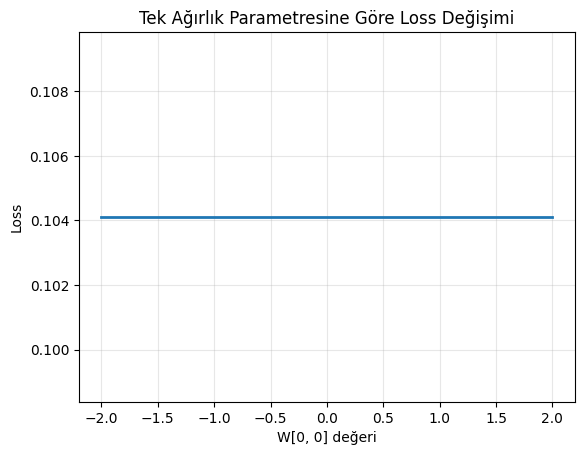

In [17]:
# 3.Faz - Backward pass: 
# Öncelikle hata (loss) hesaplanır ve ardından bu hata, modelin ağırlıklarını güncellemek için kullanılır.
# Backpropagation algoritması, zincir kuralını kullanarak her katmandaki ağırlıkların ve biasların gradyanlarını hesaplar. 
# Bu gradyanlar, modelin ağırlıklarını güncellemek için kullanılır. 
# Ağırlıklar ve biaslar, öğrenme oranı (learning rate) ile çarpılarak güncellenir. Model birsonraki iterasyonda daha doğru tahminler 
# yapabilmek için bu güncellemeleri kullanır.

# 4. Parametreleri manuel değiştirerek loss'un nasıl değiştiğini gözlemle, loss eğrisini çiz. (2. video)
# Sabit bir örnek seç
sample_idx = 0
X = data.iloc[sample_idx, 1:].values / 255.0  # Normalize et
y_true = int(data.iloc[sample_idx, 0])

# Diğer tüm ağırlıkları sabit tutup sadece W[0, 0]'ı değiştirerek loss değişimini gözlemle
W_base = np.random.randn(10, X.shape[0])
b_base = np.zeros(10)

weight_range = np.linspace(-2, 2, 200)
losses_by_weight = []
for w in weight_range:
    W = W_base.copy()
    W[0, 0] = w
    y_pred = forward_pass(X, W, b_base)
    loss = cross_entropy_loss(y_true, y_pred)
    losses_by_weight.append(loss)

plt.figure()
plt.plot(weight_range, losses_by_weight, linewidth=2)
plt.xlabel('W[0, 0] değeri')
plt.ylabel('Loss')
plt.title('Tek Ağırlık Parametresine Göre Loss Değişimi')
plt.grid(True, alpha=0.3)
plt.show()



In [18]:
# Ögrenme sürecini kolaylaştırmak için önemli ölcüde AI code üretimi kullanilmistir ama calisma mantigi icsellistirilmistir.
def gradient_descent(num_of_iters, learning_rate, X, y_true):
    W = np.random.randn(10, X.shape[0])  # (10, 784)
    b = np.zeros(10)
    losses = []
    eps = 1e-5

    for i in range(num_of_iters):
        # Forward pass
        y_pred = forward_pass(X, W, b)
        loss = cross_entropy_loss(y_true, y_pred)
        losses.append(loss)

        # Backward pass
        grad_W = np.zeros_like(W)
        for row in range(W.shape[0]):          # 10
            for col in range(W.shape[1]):      # 784
                W_temp = W.copy()
                W_temp[row, col] += eps

                y_pred_temp = forward_pass(X, W_temp, b)
                loss_temp = cross_entropy_loss(y_true, y_pred_temp)

                grad_W[row, col] = (loss_temp - loss) / eps

        # Backward pass
        grad_b = np.zeros_like(b)
        for k in range(b.shape[0]):            # 10
            b_temp = b.copy()
            b_temp[k] += eps

            y_pred_temp = forward_pass(X, W, b_temp)
            loss_temp = cross_entropy_loss(y_true, y_pred_temp)

            grad_b[k] = (loss_temp - loss) / eps

        # Parametreleri güncelle
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b

    return W, b, losses


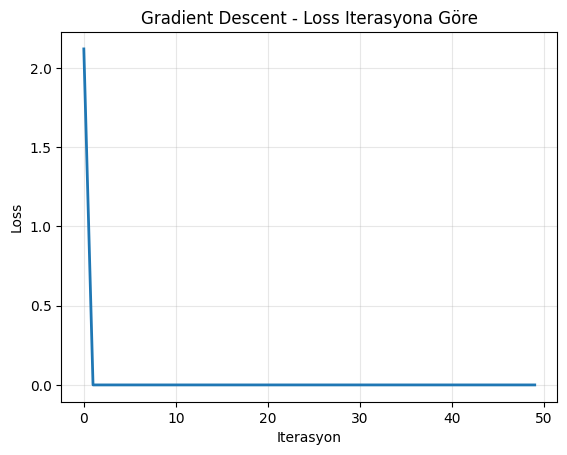

Gerçek sınıf: 2
İlk loss: 2.1193
Son loss: 0.0000
Tahmin edilen sınıf: 2
Sınıf olasılıkları: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [20]:
# Pipeline'ı çalıştır: tek bir örnek üzerinde numerical gradient descent ile eğit
W_trained, b_trained, losses = gradient_descent(num_of_iters=50, learning_rate=0.05, X=X, y_true=y_true)

plt.figure()
plt.plot(losses, linewidth=2)
plt.xlabel('Iterasyon')
plt.ylabel('Loss')
plt.title('Gradient Descent - Loss Iterasyona Göre')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Gerçek sınıf: {y_true}")
print(f"İlk loss: {losses[0]:.4f}")
print(f"Son loss: {losses[-1]:.4f}")

y_pred_final = forward_pass(X, W_trained, b_trained)
probs = softmax(y_pred_final)
print(f"Tahmin edilen sınıf: {np.argmax(probs)}")
print(f"Sınıf olasılıkları: {np.round(probs, 3)}")
